# P03. Explorando dados de sensores industriais

EDA do dataset *Microsoft Azure Predictive Maintenance*. A ideia e entender um ano de
telemetria de 100 maquinas (5 tabelas) e responder uma pergunta: os sensores mudam de
comportamento antes de uma falha? Se mudam, da pra prever falha; se nao, nao da.

Dataset sintetico, feito pra ensinar. Nao e uma fabrica real.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

## 2. Carregando os dados

In [2]:
errors    = pd.read_csv("../data/PdM_errors.csv")
failures  = pd.read_csv("../data/PdM_failures.csv")
machines  = pd.read_csv("../data/PdM_machines.csv")
maint     = pd.read_csv("../data/PdM_maint.csv")
telemetry = pd.read_csv("../data/PdM_telemetry.csv")

## 3. Primeira olhada

In [3]:
telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [4]:
for nome, df in [("telemetry", telemetry), ("errors", errors), ("failures", failures),
                 ("maint", maint), ("machines", machines)]:
    print(nome, df.shape)

telemetry (876100, 6)
errors (3919, 3)
failures (761, 3)
maint (3286, 3)
machines (100, 3)


In [5]:
telemetry.info()

<class 'pandas.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   876100 non-null  str    
 1   machineID  876100 non-null  int64  
 2   volt       876100 non-null  float64
 3   rotate     876100 non-null  float64
 4   pressure   876100 non-null  float64
 5   vibration  876100 non-null  float64
dtypes: float64(4), int64(1), str(1)
memory usage: 40.1 MB


In [6]:
machines.head()

,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


Nenhuma das 5 tabelas tem valor nulo (o `info` mostra non-null = total em tudo). A coluna
`datetime` veio como texto, vou converter na seção 6, quando precisar dela.

## 4. As máquinas

In [7]:
machines["model"].value_counts()

model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

In [8]:
machines["age"].describe()

count    100.000000
mean      11.330000
std        5.856974
min        0.000000
25%        6.750000
50%       12.000000
75%       16.000000
max       20.000000
Name: age, dtype: float64

In [9]:
machines.groupby("model")["age"].agg(["mean", "median", "count"])

,mean,median,count
model,,,
model1,12.250000,14.0,16
model2,12.764706,14.0,17
model3,12.028571,14.0,35
model4,9.343750,9.5,32


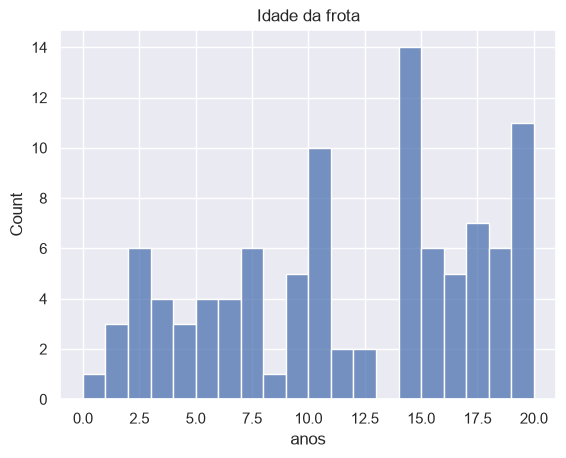

In [10]:
sns.histplot(data=machines, x="age", bins=20)
plt.title("Idade da frota")
plt.xlabel("anos");

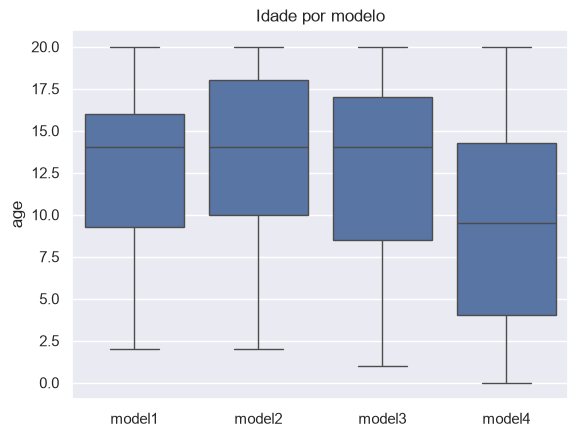

In [11]:
sns.boxplot(data=machines, x="model", y="age", order=["model1", "model2", "model3", "model4"])
plt.title("Idade por modelo")
plt.xlabel("");

Idade espalhada de 0 a 20 anos, meio uniforme (média ~11, mediana 12). O model1, model2 e
model3 têm idade quase igual entre si (mediana 14), mas o model4 é bem mais novo (mediana 9,5).
Isso vai atrapalhar comparar "qual modelo é mais confiável" mais pra frente, porque máquina
nova falha menos de qualquer jeito.

## 5. Os sensores

In [12]:
sensores = ["volt", "rotate", "pressure", "vibration"]
telemetry[sensores].describe()

,volt,rotate,pressure,vibration
count,876100.000000,876100.000000,876100.000000,876100.000000
mean,170.777736,446.605119,100.858668,40.385007
std,15.509114,52.673886,11.048679,5.370361
min,97.333604,138.432075,51.237106,14.877054
25%,160.304927,412.305714,93.498181,36.777299
50%,170.607338,447.558150,100.425559,40.237247
75%,181.004493,482.176600,107.555231,43.784938
max,255.124717,695.020984,185.951998,76.791072


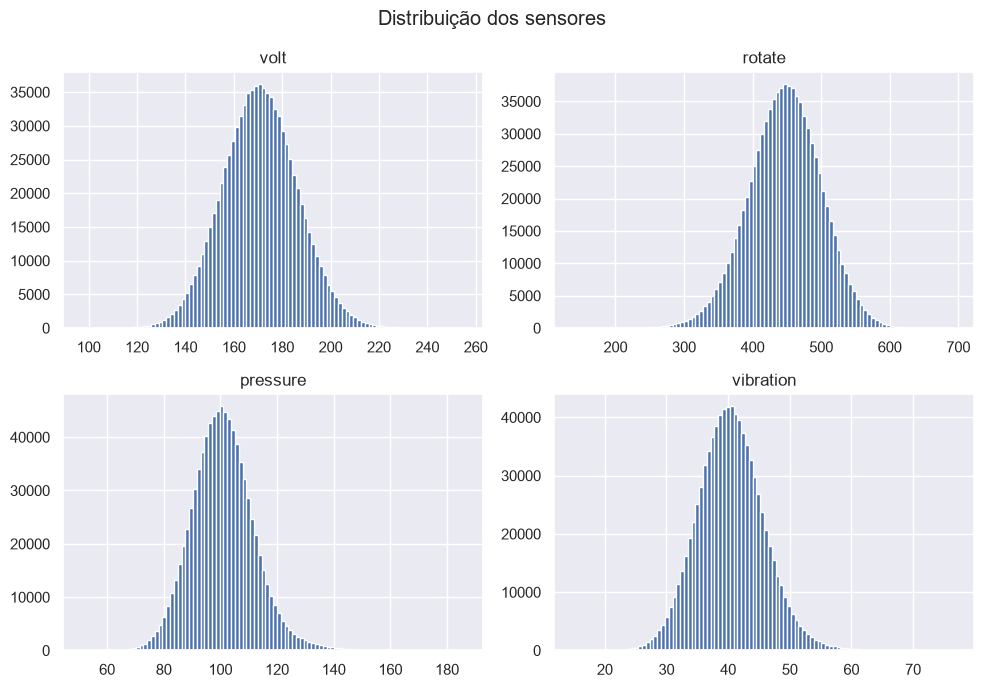

In [13]:
telemetry[sensores].hist(figsize=(10, 7), bins=100, layout=(2, 2))
plt.suptitle("Distribuição dos sensores")
plt.tight_layout()
plt.savefig("../images/sensores_hist.png", dpi=120, bbox_inches="tight")

In [14]:
telemetry[sensores].corr()

,volt,rotate,pressure,vibration
volt,1.000000,-0.001511,0.001652,0.002390
rotate,-0.001511,1.000000,-0.000688,-0.003056
pressure,0.001652,-0.000688,1.000000,0.001395
vibration,0.002390,-0.003056,0.001395,1.000000


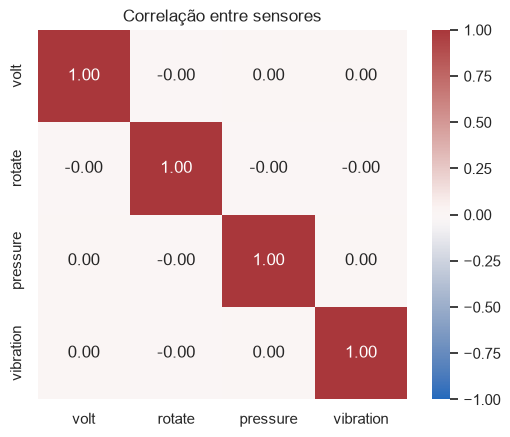

In [15]:
sns.heatmap(telemetry[sensores].corr(), annot=True, fmt=".2f", cmap="vlag",
            center=0, vmin=-1, vmax=1, square=True)
plt.title("Correlação entre sensores");

Os 4 sensores têm cara de gaussiana em torno de um valor de operação. Pressão e vibração
puxam um pouco pra direita (cauda). A correlação entre sensores diferentes, medida no ano
todo, é praticamente zero, então cada um carrega informação própria. Numa bomba real eu
esperaria rotação e pressão andando juntas; aqui não andam, provavelmente porque o dado foi
gerado com cada sensor independente.

## 6. Uma máquina ao longo do tempo

In [16]:
telemetry["datetime"] = pd.to_datetime(telemetry["datetime"])
telemetry["datetime"].dtype

dtype('<M8[us]')

In [17]:
m1 = telemetry[telemetry["machineID"] == 1].sort_values("datetime")
m1.shape

(8761, 6)

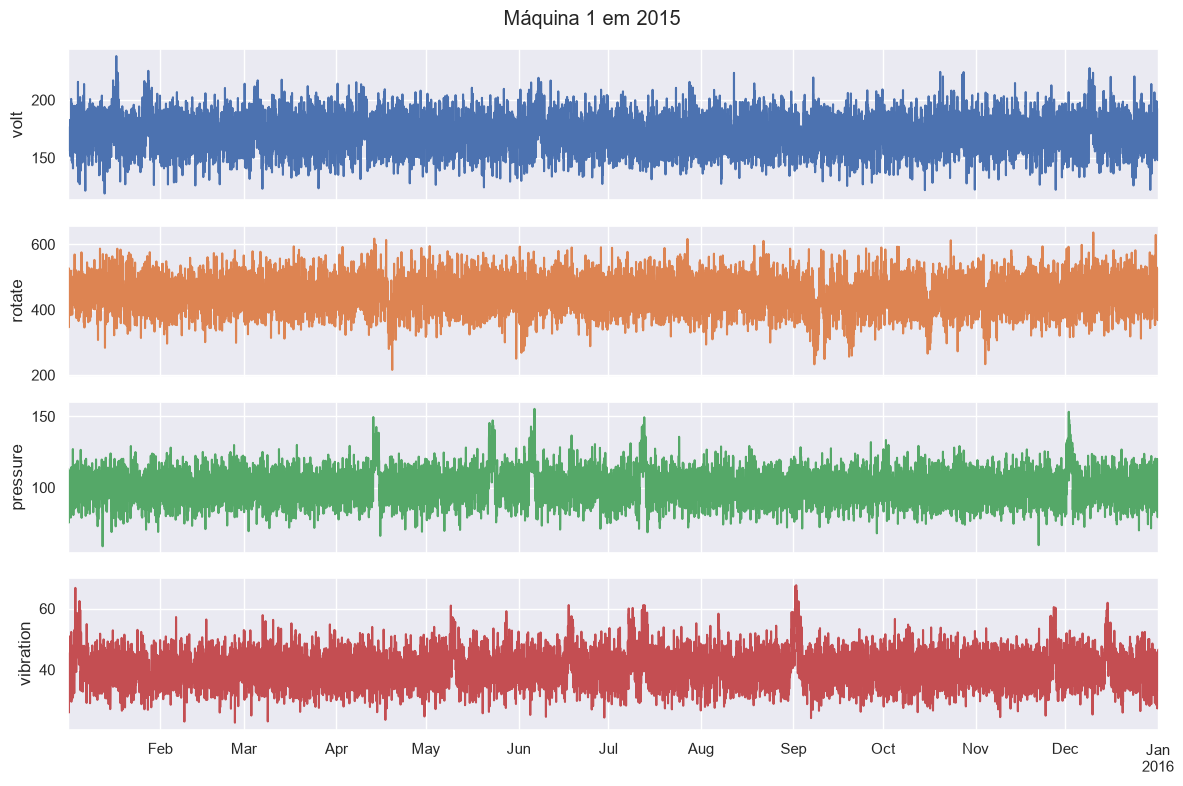

In [18]:
eixos = m1.plot(x="datetime", y=sensores, subplots=True, figsize=(12, 8), legend=False)
for ax, s in zip(eixos, sensores):
    ax.set_ylabel(s)
eixos[-1].set_xlabel("")
eixos[0].figure.suptitle("Máquina 1 em 2015")
plt.tight_layout();

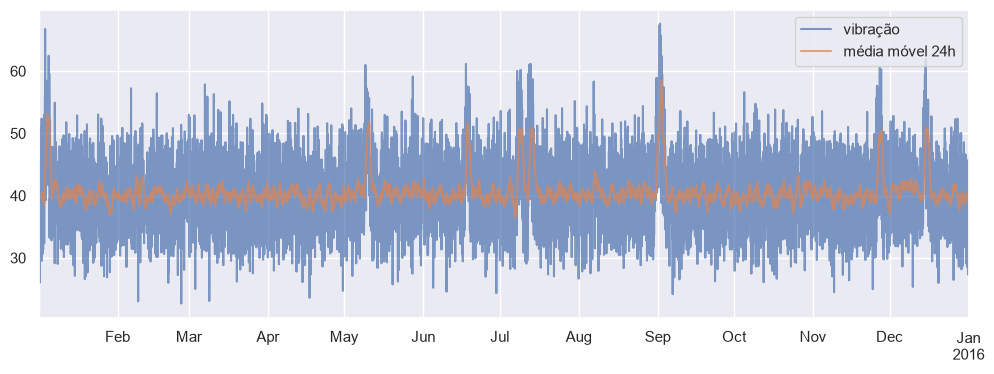

In [19]:
# media movel de 24h pra ver tendencia debaixo do ruido
m1 = m1.copy()
m1["vib_mm24"] = m1["vibration"].rolling(24).mean()
m1.plot(x="datetime", y=["vibration", "vib_mm24"], figsize=(12, 4), alpha=0.7)
plt.legend(["vibração", "média móvel 24h"])
plt.xlabel("");

No zoom do ano inteiro os 4 sensores são faixas ruidosas e planas, sem tendência de longo
prazo (a média móvel fica reta). Dá pra ver uns picos coordenados em alguns pontos do ano
(início de setembro, por exemplo), que devem ser as falhas. Nesse zoom não dá pra ver mais
que isso, por isso a seção 8 recorta janelas curtas.

## 7. Erros, falhas e manutenção

In [20]:
for df in (errors, failures, maint):
    df["datetime"] = pd.to_datetime(df["datetime"])

In [21]:
errors["errorID"].value_counts()

errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64

In [22]:
errors["machineID"].value_counts().describe()

count    100.000000
mean      39.190000
std        6.882411
min       22.000000
25%       35.000000
50%       39.000000
75%       43.000000
max       60.000000
Name: count, dtype: float64

Os 5 tipos de erro aparecem todos com frequência parecida, sem um dominante. E os erros são
bem parelhos entre máquinas: todas as 100 aparecem, média ~39 por ano, desvio pequeno.

In [23]:
failures["failure"].value_counts()

failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

In [24]:
failures["machineID"].value_counts().describe()

count    98.000000
mean      7.765306
std       3.463509
min       2.000000
25%       5.000000
50%       7.000000
75%      10.000000
max      19.000000
Name: count, dtype: float64

O comp2 é o que mais quebra (259 de 761, uns 34%). E repara no `count`: 98, não 100. Ou seja,
2 máquinas passaram o ano inteiro sem nenhuma falha, enquanto tem máquina com 19. As falhas
são bem mais concentradas entre máquinas do que os erros.

In [25]:
taxa = len(failures) / machines["machineID"].nunique()
print(f"{len(failures)} falhas / 100 máquinas / 1 ano = {taxa:.1f} por máquina-ano")

761 falhas / 100 máquinas / 1 ano = 7.6 por máquina-ano


In [26]:
fm = failures.merge(machines, on="machineID")
por_modelo = fm.groupby("model")["failure"].count() / machines["model"].value_counts()
por_modelo.sort_values()

model
model4     5.718750
model3     6.314286
model2     9.882353
model1    11.812500
dtype: float64

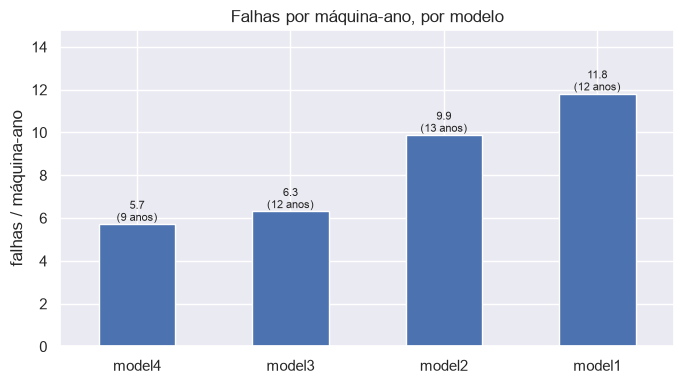

In [27]:
idade_media = machines.groupby("model")["age"].mean()
por_modelo = por_modelo.sort_values()
ax = por_modelo.plot(kind="bar", figsize=(7, 4), color="#4C72B0", rot=0)
ax.set_ylim(0, por_modelo.max() * 1.25)
plt.title("Falhas por máquina-ano, por modelo")
plt.xlabel("")
plt.ylabel("falhas / máquina-ano")
for i, mod in enumerate(por_modelo.index):
    plt.text(i, por_modelo[mod] + 0.15, f"{por_modelo[mod]:.1f}\n({idade_media[mod]:.0f} anos)",
             ha="center", fontsize=8)
plt.tight_layout()
plt.savefig("../images/falhas_por_modelo.png", dpi=120, bbox_inches="tight")

model1 (11,8) e model2 (9,9) falham quase o dobro do model3 (6,3), e os três têm a mesma
idade média (~12 anos). Então aqui parece ter efeito de modelo mesmo, não só idade. O model4
tem a menor taxa (5,7), mas é o mais novo (~9 anos), então esse não dá pra afirmar.

In [28]:
maint["comp"].value_counts()

comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64

`maint` tem 3286 registros contra 761 falhas. Como toda falha vira uma troca, sobra ~2500
manutenção preventiva (uns 77%). E as trocas se dividem quase igual entre os 4 componentes,
não seguem quem falha mais. É uma frota com manutenção agendada, não reativa.

In [29]:
# os erros acontecem antes da falha? comparo com o que seria por acaso
janelas = failures.rename(columns={"datetime": "t_falha"})[["machineID", "t_falha"]]
e = errors.merge(janelas, on="machineID")
e["horas_antes"] = (e["t_falha"] - e["datetime"]).dt.total_seconds() / 3600
pre_erros = e[(e["horas_antes"] > 0) & (e["horas_antes"] <= 24)]

por_acaso = len(errors) / len(telemetry) * 24 * len(failures)
com_erro = pre_erros.groupby(["machineID", "t_falha"]).ngroups
print(f"erros nas 24h antes de uma falha: {len(pre_erros)}  (por acaso seriam ~{por_acaso:.0f})")
print(f"falhas com pelo menos 1 erro nas 24h anteriores: {com_erro} de {len(failures)}")

erros nas 24h antes de uma falha: 1177  (por acaso seriam ~82)
falhas com pelo menos 1 erro nas 24h anteriores: 705 de 761


Isso é forte: 705 das 761 falhas (93%) têm algum erro registrado nas 24 h antes, contra os
~80 erros que cairiam nessa janela se fosse tudo aleatório. Os erros já são um aviso.

## 8. O sinal antes da falha

In [30]:
failures[failures["machineID"] == 1]

,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4
5,2015-10-17 06:00:00,1,comp2
6,2015-12-16 06:00:00,1,comp4


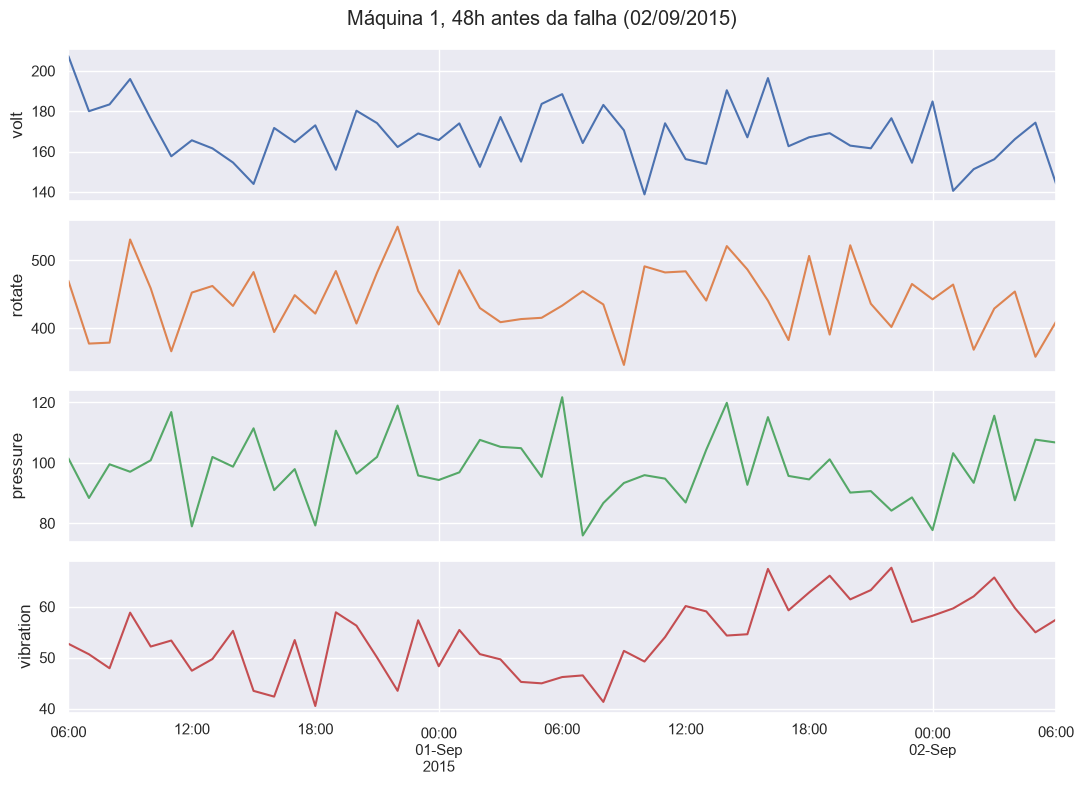

In [31]:
t_falha = pd.Timestamp("2015-09-02 06:00:00")   # maquina 1, comp4
ini = t_falha - pd.Timedelta(hours=48)
janela = m1[(m1["datetime"] >= ini) & (m1["datetime"] <= t_falha)]

eixos = janela.plot(x="datetime", y=sensores, subplots=True, figsize=(11, 8), legend=False)
for ax, s in zip(eixos, sensores):
    ax.set_ylabel(s)
eixos[-1].set_xlabel("")
eixos[0].figure.suptitle("Máquina 1, 48h antes da falha (02/09/2015)")
plt.tight_layout()
plt.savefig("../images/janela_pre_falha.png", dpi=120, bbox_inches="tight")

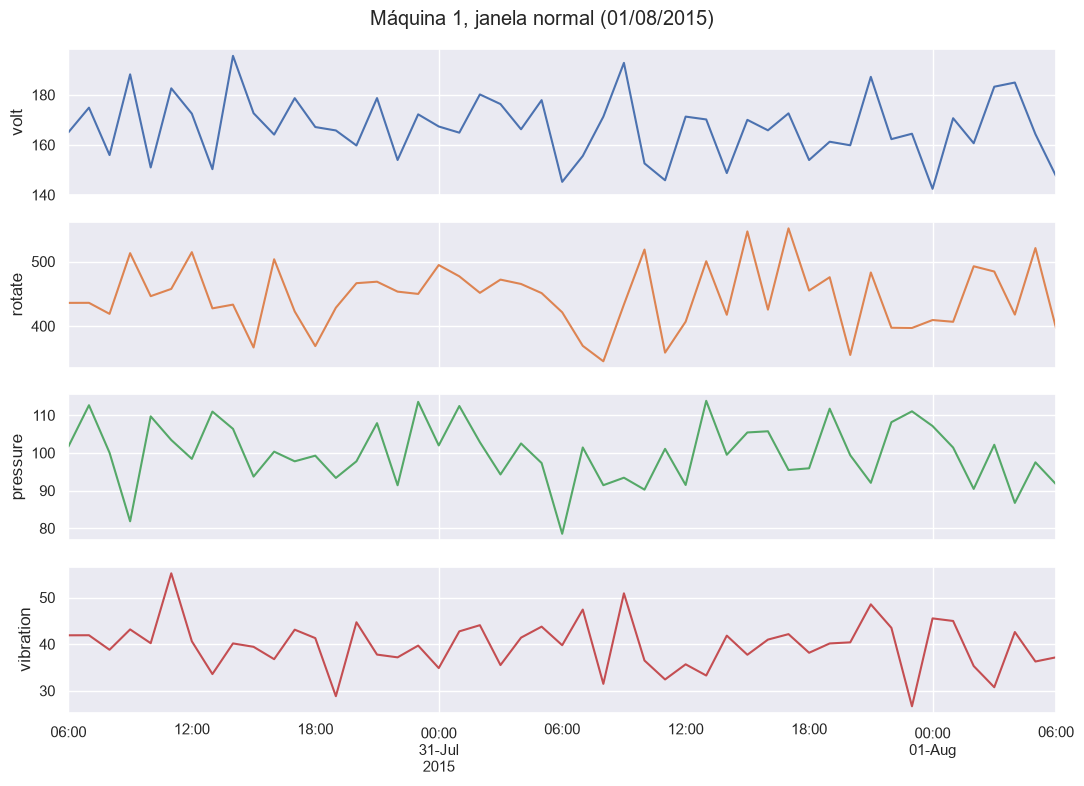

In [32]:
# mesma maquina, periodo calmo, pra comparar
t_ref = pd.Timestamp("2015-08-01 06:00:00")
janela_ok = m1[(m1["datetime"] >= t_ref - pd.Timedelta(hours=48)) & (m1["datetime"] <= t_ref)]

eixos = janela_ok.plot(x="datetime", y=sensores, subplots=True, figsize=(11, 8), legend=False)
for ax, s in zip(eixos, sensores):
    ax.set_ylabel(s)
eixos[-1].set_xlabel("")
eixos[0].figure.suptitle("Máquina 1, janela normal (01/08/2015)")
plt.tight_layout();

Na janela normal os 4 sensores ficam planos. Na janela antes da falha a vibração sai de ~45
e sobe pra faixa de 60 a 70 nas últimas ~15 h, e a pressão também levanta um pouco. Rotação e
tensão não mostram muita coisa nesse caso.

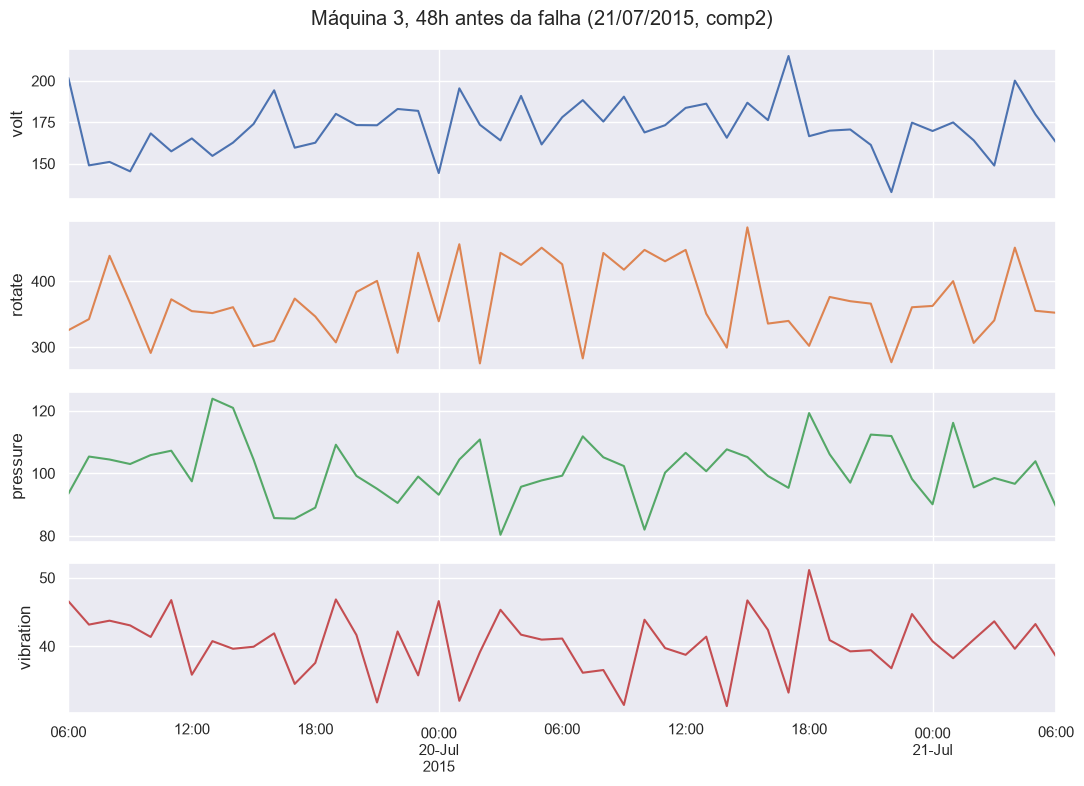

In [33]:
# um segundo caso, outra maquina e outro componente
t2 = pd.Timestamp("2015-07-21 06:00:00")   # maquina 3, comp2
m3 = telemetry[telemetry["machineID"] == 3].sort_values("datetime")
janela2 = m3[(m3["datetime"] >= t2 - pd.Timedelta(hours=48)) & (m3["datetime"] <= t2)]

eixos = janela2.plot(x="datetime", y=sensores, subplots=True, figsize=(11, 8), legend=False)
for ax, s in zip(eixos, sensores):
    ax.set_ylabel(s)
eixos[-1].set_xlabel("")
eixos[0].figure.suptitle("Máquina 3, 48h antes da falha (21/07/2015, comp2)")
plt.tight_layout();

In [34]:
# agora sem escolher a dedo: marco toda leitura nas 24h antes de qualquer falha
telemetry["pre_falha"] = False
for _, f in failures.iterrows():
    ini = f["datetime"] - pd.Timedelta(hours=24)
    m = ((telemetry["machineID"] == f["machineID"])
         & (telemetry["datetime"] >= ini)
         & (telemetry["datetime"] < f["datetime"]))
    telemetry.loc[m, "pre_falha"] = True

telemetry["pre_falha"].value_counts()

pre_falha
False    858916
True      17184
Name: count, dtype: int64

In [35]:
media = telemetry.groupby("pre_falha")[sensores].mean()
media

,volt,rotate,pressure,vibration
pre_falha,,,,
False,170.674551,447.166188,100.769813,40.337682
True,175.935276,418.560949,105.299940,42.750475


In [36]:
# quanto isso representa em desvios-padrao de cada sensor
((media.loc[True] - media.loc[False]) / telemetry[sensores].std()).round(2)

volt         0.34
rotate      -0.54
pressure     0.41
vibration    0.45
dtype: float64

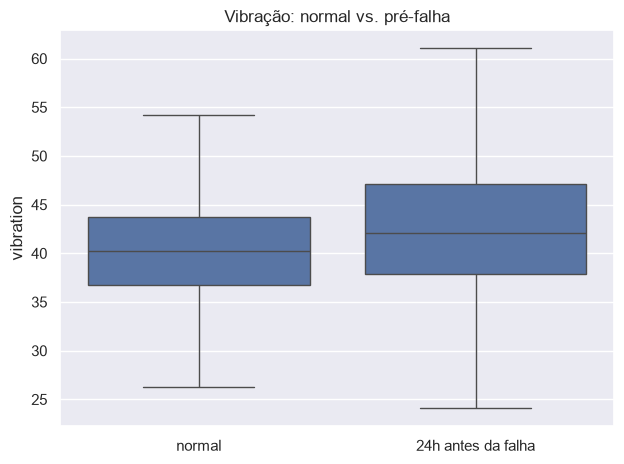

In [37]:
sns.boxplot(data=telemetry, x="pre_falha", y="vibration", order=[False, True], showfliers=False)
plt.xticks([0, 1], ["normal", "24h antes da falha"])
plt.xlabel("")
plt.title("Vibração: normal vs. pré-falha")
plt.tight_layout()
plt.savefig("../images/vibracao_pre_falha.png", dpi=120, bbox_inches="tight")

No agregado das 761 falhas o padrão se mantém: nas 24 h antes a média da vibração e da
pressão sobe, a da rotação cai, tudo junto, coisa de meio desvio-padrão mesmo diluído na
janela inteira (nas horas finais é bem mais). O segundo caso (máquina 3) mostra o aviso mais
sutil que o da máquina 1, então nem toda falha avisa com a mesma força, mas na média avisa.

## 9. Conclusões

O dado é limpo: nenhum nulo nas 5 tabelas, telemetria horária e regular no ano de 2015. A
frota tem 4 modelos e idades de 0 a 20 anos, mas o model4 é bem mais novo que os outros três,
o que atrapalha comparar confiabilidade por modelo.

Os 4 sensores oscilam em torno de um valor de operação com cara de ruído gaussiano e, olhados
no ano todo, são praticamente descorrelacionados entre si.

Sobre as falhas: dá umas 7,6 por máquina por ano, o comp2 é o que mais quebra, e elas se
concentram (2 máquinas passaram o ano sem falhar, outra falhou 19 vezes). Entre modelos de
mesma idade o model1 e o model2 falham quase o dobro do model3, então parece ter efeito de
modelo além da idade. A manutenção é quase toda preventiva.

O ponto principal é que a falha avisa antes. Nas 48 h antes da falha da máquina 1 a vibração
vai de ~45 pra ~70 nas últimas 15 h, enquanto numa janela normal da mesma máquina fica plana.
No agregado das 761 falhas a média dos sensores desloca junto (vibração e pressão pra cima,
rotação pra baixo). E 93% das falhas têm pelo menos um erro registrado nas 24 h anteriores,
contra quase nada se fosse aleatório.

Ou seja, dá pra prever. Pro P08 eu começaria com média e desvio móvel de 24 h da vibração e
da rotação, mais a contagem de erros recentes, com alvo "vai falhar nas próximas 12 a 24 h".
Ressalvas: dado sintético, e a correlação entre sensores foi medida só no ano inteiro, não
por regime de operação.